### Loading Predicted Returns (ML Outputs)

We load the predicted returns generated from the machine learning pipeline for both:

- Full universe of assets
- Extended universe (with longer historical coverage)

These predictions represent the expected returns $\mu_i$ used as inputs to the QUBO formulation.

The dimensions of each dataset are verified to ensure consistency with the corresponding asset universes.

In [1]:
import pandas as pd
import numpy as np

# Load predicted returns
mu_full_universe = pd.read_csv("ml_predictions_full_universe.csv")
mu_extended_universe = pd.read_csv("ml_predictions_extended_universe.csv")

print("Full universe size:", len(mu_full_universe))
print("Extended universe size:", len(mu_extended_universe))

Full universe size: 562
Extended universe size: 562


In [3]:
mu_full_universe.head()

,Date,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,...,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,VEDL,WIPRO,ZEEL
0,2019-01-01,0.088575,0.105329,0.116347,0.116083,0.100023,0.095051,0.133317,0.092907,0.111688,...,0.111827,0.102693,0.122068,0.088926,0.085999,0.112034,0.114034,0.094014,0.106123,0.095896
1,2019-01-02,0.106512,0.112139,0.101756,0.118102,0.101933,0.091265,0.117594,0.085066,0.113869,...,0.118914,0.128010,0.108818,0.101994,0.102723,0.116233,0.122194,0.107970,0.123626,0.107192
2,2019-01-03,0.135027,0.104282,0.119401,0.135191,0.127329,0.118650,0.146769,0.122262,0.104894,...,0.148175,0.166173,0.106467,0.120674,0.091676,0.115791,0.113687,0.161443,0.122553,0.143701
3,2019-01-04,0.135958,0.106492,0.143539,0.121490,0.121442,0.127579,0.130413,0.122354,0.106792,...,0.147769,0.168174,0.122070,0.150258,0.111512,0.147883,0.136620,0.165769,0.126410,0.157833
4,2019-01-07,0.112823,0.109698,0.100200,0.108748,0.103095,0.120100,0.088551,0.092914,0.106867,...,0.101618,0.141419,0.127500,0.143278,0.111700,0.120010,0.115108,0.121750,0.127294,0.137366


In [5]:
mu_extended_universe.head()

,Date,ASIANPAINT,AXISBANK,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,DRREDDY,EICHERMOT,...,SBIN,SHREECEM,SUNPHARMA,TATAMOTORS,TATASTEEL,TITAN,UPL,VEDL,WIPRO,ZEEL
0,2019-01-01,0.159511,0.146797,0.169349,0.195407,0.191426,0.141098,0.146232,0.143760,0.166348,...,0.147853,0.162771,0.159959,0.164378,0.136538,0.119253,0.163710,0.156167,0.144542,0.121611
1,2019-01-02,0.168043,0.136255,0.173666,0.170008,0.188088,0.153560,0.139137,0.153481,0.161010,...,0.140021,0.169130,0.163614,0.177438,0.152753,0.128249,0.182854,0.147186,0.156422,0.152577
2,2019-01-03,0.166139,0.150577,0.184911,0.198717,0.194182,0.145449,0.140518,0.142650,0.218672,...,0.162859,0.158322,0.175636,0.192374,0.166222,0.125609,0.164886,0.170929,0.136202,0.193293
3,2019-01-04,0.181041,0.183473,0.199397,0.190423,0.193434,0.156883,0.136085,0.155611,0.196319,...,0.174735,0.176834,0.205388,0.190938,0.161858,0.143771,0.182125,0.168595,0.141690,0.202168
4,2019-01-07,0.199934,0.155566,0.198481,0.177684,0.179958,0.169404,0.133009,0.146671,0.179094,...,0.157479,0.191984,0.199340,0.167702,0.141740,0.152295,0.172519,0.137353,0.152198,0.192692


### Preparing QUBO Inputs

We extract the predicted returns as a vector $\mu$ and store the corresponding asset names for both universes. These serve as inputs to the QUBO optimization.

In [7]:
# remove date column
returns_full = mu_full_universe.drop(columns=["Date"])
returns_extended = mu_extended_universe.drop(columns=["Date"])

# extract predicted returns (single row)
r_full = returns_full.iloc[0].values
r_extended = returns_extended.iloc[0].values

# asset names
assets_full = returns_full.columns.values
assets_extended = returns_extended.columns.values

# number of assets
N_full = len(r_full)
N_extended = len(r_extended)

print("Full universe assets:", N_full)
print("Extended universe assets:", N_extended)

Full universe assets: 50
Extended universe assets: 38


### Constraint and Penalty Parameter

We enforce a cardinality constraint by selecting a fixed number of assets ($K=10$).  
The penalty parameter $\lambda$ is scaled relative to the magnitude of returns to ensure the constraint is effectively enforced in the QUBO formulation.

In [9]:
# Number of assets to select
K = 10

print("Portfolio size constraint:", K)

Portfolio size constraint: 10


In [11]:
# compute average magnitude of returns
avg_r_full = np.mean(np.abs(r_full))
avg_r_extended = np.mean(np.abs(r_extended))

# choose penalty parameter
lam_full = 10 * avg_r_full
lam_extended = 10 * avg_r_extended

print("Lambda (full universe):", lam_full)
print("Lambda (extended universe):", lam_extended)

Lambda (full universe): 1.0707830150509936
Lambda (extended universe): 1.533378529530835


### Loading Covariance Matrices

We load the covariance matrices for both universes, which capture the risk and correlations between assets. These are used in the quadratic term of the QUBO objective.

In [21]:
base_path = r"D:\CMI\IP"

# Load covariance matrices
cov_full = pd.read_csv(f"{base_path}\\cov_full_universe.csv", index_col=0)
cov_ext = pd.read_csv(f"{base_path}\\cov_extended_universe.csv", index_col=0)

# Convert to numpy arrays
Sigma_full = cov_full.values
Sigma_ext = cov_ext.values

print("Full covariance shape:", Sigma_full.shape)
print("Extended covariance shape:", Sigma_ext.shape)

Full covariance shape: (50, 50)
Extended covariance shape: (38, 38)


### QUBO Formulation with Covariance (Mean-Variance Portfolio)

We define binary decision variables:

$$
x_i \in \{0,1\}
$$

---

### Objective

We consider the mean-variance objective with a cardinality constraint:

$$
\min_x
\left(
-\sum_i \mu_i x_i
+
\gamma \sum_{i,j} \Sigma_{ij} x_i x_j
+
\lambda \left(\sum_i x_i - K\right)^2
\right)
$$

---

### Expand the Penalty Term

$$
\lambda \left(\sum_i x_i - K\right)^2
=
\lambda \left[
\left(\sum_i x_i\right)^2
- 2K \sum_i x_i
+ K^2
\right]
$$

Expand:

$$
\left(\sum_i x_i\right)^2
=
\sum_i x_i^2 + 2\sum_{i<j} x_i x_j
$$

Using $x_i^2 = x_i$:

$$
=
\sum_i x_i + 2\sum_{i<j} x_i x_j
$$

Substitute back:

$$
=
\lambda \left(
-(2K-1)\sum_i x_i
+
2\sum_{i<j} x_i x_j
\right)
+ \text{const}
$$

---

### Expand the Covariance Term

$$
\gamma \sum_{i,j} \Sigma_{ij} x_i x_j
$$

Split into diagonal and off-diagonal:

$$
=
\gamma \left(
\sum_i \Sigma_{ii} x_i^2
+
\sum_{i \ne j} \Sigma_{ij} x_i x_j
\right)
$$

Using $x_i^2 = x_i$:

$$
=
\gamma \left(
\sum_i \Sigma_{ii} x_i
+
\sum_{i \ne j} \Sigma_{ij} x_i x_j
\right)
$$

Convert to $i<j$ form:

$$
\sum_{i \ne j} \Sigma_{ij} x_i x_j
=
2\sum_{i<j} \Sigma_{ij} x_i x_j
$$

So:

$$
=
\gamma \sum_i \Sigma_{ii} x_i
+
2\gamma \sum_{i<j} \Sigma_{ij} x_i x_j
$$

---

### Final QUBO Objective

$$
E(x) =
\sum_i Q_{ii} x_i
+
\sum_{i<j} Q_{ij} x_i x_j
$$

---

### QUBO Coefficients

### Diagonal terms

$$
Q_{ii} =
-\mu_i
+
\gamma \Sigma_{ii}
-
(2K-1)\lambda
$$

For $K = 10$:

$$
Q_{ii} =
-\mu_i
+
\gamma \Sigma_{ii}
-
19\lambda
$$

---

### Off-diagonal terms

$$
Q_{ij} =
2\gamma \Sigma_{ij}
+
2\lambda
\quad (i < j)
$$

---

### Notes

- The constant term does not affect optimization and is ignored.
- Each pair $(i,j)$ appears once using the $i<j$ formulation.
- The factor of 2 accounts for symmetry in the original double summation.

----

In [24]:
import numpy as np

def build_qubo_upper(mu, Sigma, gamma=1.0, lam=10.0, K=10):
    N = len(mu)
    Q = np.zeros((N, N))

    # Diagonal
    for i in range(N):
        Q[i, i] = -mu[i] + gamma * Sigma[i, i] - (2*K - 1) * lam

    # Upper triangle only
    for i in range(N):
        for j in range(i+1, N):
            Q[i, j] = 2 * gamma * Sigma[i, j] + 2 * lam

    return Q

In [30]:
Q_full = build_qubo_upper(r_full, Sigma_full, gamma=0.5, lam=10, K=10)
Q_ext  = build_qubo_upper(r_extended,  Sigma_ext,  gamma=0.5, lam=10, K=10)

print("Q_full shape:", Q_full.shape)
print("Q_ext shape:", Q_ext.shape)

Q_full shape: (50, 50)
Q_ext shape: (38, 38)


----

### QUBO Matrix Representation

The QUBO matrix is converted into a dictionary format using only the upper triangular entries. This avoids redundant storage due to symmetry and matches the input format required by the sampler.

In [40]:
def matrix_to_qubo_dict(Q):
    Q_dict = {}
    N = Q.shape[0]
    
    for i in range(N):
        for j in range(i, N):  # upper triangle only
            if Q[i, j] != 0:
                Q_dict[(i, j)] = Q[i, j]
    
    return Q_dict

In [42]:
Q_full_dict = matrix_to_qubo_dict(Q_full)
Q_ext_dict  = matrix_to_qubo_dict(Q_ext)

### QUBO Optimization via Simulated Annealing

We solve the QUBO using a simulated annealing sampler. The best solution is selected and converted into a binary decision vector, indicating the chosen assets. We verify constraint satisfaction and evaluate the objective value for the resulting portfolio.

In [44]:
import neal

sampler = neal.SimulatedAnnealingSampler()

sampleset_full = sampler.sample_qubo(Q_full_dict, num_reads=1000)
sampleset_ext  = sampler.sample_qubo(Q_ext_dict,  num_reads=1000)

In [176]:
best_full = sampleset_full.first.sample
best_ext  = sampleset_ext.first.sample

# Convert dict to array
x_full = np.array([best_full[i] for i in range(len(r_full))])
x_ext  = np.array([best_ext[i]  for i in range(len(r_extended))])

print("Full universe selection:", x_full.sum())
print("Extended universe selection:", x_ext.sum())

Full universe selection: 10
Extended universe selection: 10


In [48]:
print("Full objective:",
      original_objective(x_full, r_full, Sigma_full, gamma=0.5, lam=10, K=10))

print("Extended objective:",
      original_objective(x_ext, r_extended, Sigma_ext, gamma=0.5, lam=10, K=10))

Full objective: -0.2101200427133838
Extended objective: 0.07976558483928686


In [50]:
import numpy as np

def portfolio_return(x, r):
    return np.dot(r, x)

def portfolio_variance(x, Sigma):
    return x @ Sigma @ x

def evaluate_portfolio(x, r, Sigma):
    return {
        "return": portfolio_return(x, r),
        "variance": portfolio_variance(x, Sigma),
        "selected": int(x.sum())
    }

In [208]:
def solve_qubo(r, Sigma, gamma, lam=10, K=10, num_reads=2000):
    Q = build_qubo_upper(r, Sigma, gamma=gamma, lam=lam, K=K)
    Q_dict = matrix_to_qubo_dict(Q)

    sampleset = sampler.sample_qubo(Q_dict, num_reads=num_reads)
    best = sampleset.first.sample

    x = np.array([best[i] for i in range(len(r))])
    return x

### QUBO Portfolio Construction (Full vs Extended Universes)

We construct portfolios for both universes simultaneously across a range of $\gamma$ values.

For each $\gamma$, we:
- Solve the QUBO
- Extract selected assets
- Assign equal weights
- Store portfolios for later backtesting

In [232]:
gammas = [0.05, 0.5, 5, 15, 30, 60, 100]

qubo_weights_full = {}
qubo_weights_ext = {}

for g in gammas:
    # ---- FULL UNIVERSE ----
    x_full = solve_qubo(r_full, Sigma_full, gamma=g, lam=50)
    idx_full = np.where(x_full == 1)[0]
    assets_sel_full = assets_full[idx_full]

    w_full = pd.Series(1/len(assets_sel_full), index=assets_sel_full)
    qubo_weights_full[g] = w_full

    # ---- EXTENDED UNIVERSE ----
    x_ext = solve_qubo(r_extended, Sigma_ext, gamma=g, lam=50)
    idx_ext = np.where(x_ext == 1)[0]
    assets_sel_ext = assets_extended[idx_ext]

    w_ext = pd.Series(1/len(assets_sel_ext), index=assets_sel_ext)
    qubo_weights_ext[g] = w_ext

    # ---- PRINT ----
    print(f"\n==============================")
    print(f"Gamma = {g}")
    print(f"==============================")

    print("\n--- FULL UNIVERSE ---")
    print("Count:", len(assets_sel_full))
    print(assets_sel_full)

    print("\n--- EXTENDED UNIVERSE ---")
    print("Count:", len(assets_sel_ext))
    print(assets_sel_ext)


Gamma = 0.05

--- FULL UNIVERSE ---
Count: 10
['BAJAJFINSV' 'COALINDIA' 'DRREDDY' 'EICHERMOT' 'HCLTECH' 'HEROMOTOCO'
 'HINDUNILVR' 'MARUTI' 'NESTLEIND' 'SUNPHARMA']

--- EXTENDED UNIVERSE ---
Count: 10
['BHARTIARTL' 'CIPLA' 'EICHERMOT' 'HEROMOTOCO' 'INFY' 'IOC' 'KOTAKBANK'
 'ONGC' 'TATAMOTORS' 'UPL']

Gamma = 0.5

--- FULL UNIVERSE ---
Count: 10
['BRITANNIA' 'COALINDIA' 'GAIL' 'HEROMOTOCO' 'HINDUNILVR' 'MM' 'NESTLEIND'
 'SUNPHARMA' 'TCS' 'UPL']

--- EXTENDED UNIVERSE ---
Count: 10
['ASIANPAINT' 'BRITANNIA' 'CIPLA' 'DRREDDY' 'GAIL' 'GRASIM' 'HEROMOTOCO'
 'SHREECEM' 'SUNPHARMA' 'WIPRO']

Gamma = 5

--- FULL UNIVERSE ---
Count: 10
['BAJAJFINSV' 'BHARTIARTL' 'CIPLA' 'DRREDDY' 'GAIL' 'HCLTECH' 'HDFC'
 'HEROMOTOCO' 'ITC' 'NESTLEIND']

--- EXTENDED UNIVERSE ---
Count: 10
['ASIANPAINT' 'BHARTIARTL' 'BRITANNIA' 'CIPLA' 'DRREDDY' 'EICHERMOT'
 'HINDUNILVR' 'INFY' 'IOC' 'TITAN']

Gamma = 15

--- FULL UNIVERSE ---
Count: 10
['BAJAJ-AUTO' 'BAJAJFINSV' 'HINDUNILVR' 'MARUTI' 'NESTLEIND' 'NTPC'
 'POWE

### QUBO Portfolio (Equal Weight)

We evaluate QUBO-selected portfolios using out-of-sample returns.

For each gamma:
- Use equal-weight portfolio over selected assets
- Compute daily portfolio returns
- Annualize return and volatility
- Compute Sharpe ratio

This matches the evaluation used for ML Markowitz portfolios.

In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_portfolios(portfolio_returns_dict, title_prefix):
    summary = []

    plt.figure(figsize=(12, 6))

    for key, rets in portfolio_returns_dict.items():
        rets = rets.dropna()

        ann_return = rets.mean() * 252
        ann_vol = rets.std() * np.sqrt(252)
        sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

        summary.append({
            "Gamma": key,
            "Annualized Return": ann_return,
            "Annualized Volatility": ann_vol,
            "Sharpe Ratio": sharpe
        })

        cum_returns = (1 + rets).cumprod()
        plt.plot(cum_returns, label=f"Gamma={key}")

    plt.title(f"Cumulative Returns - {title_prefix}")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid(True)
    plt.show()

    return pd.DataFrame(summary)

In [236]:
portfolio_returns_qubo_full = {}

for g, w in qubo_weights_full.items():
    assets = w.index.intersection(test_returns_full.columns)
    portfolio_returns_qubo_full[g] = test_returns_full[assets] @ w[assets]

In [238]:
portfolio_returns_qubo_ext = {}

for g, w in qubo_weights_ext.items():
    assets = w.index.intersection(test_returns_ext.columns)
    portfolio_returns_qubo_ext[g] = test_returns_ext[assets] @ w[assets]

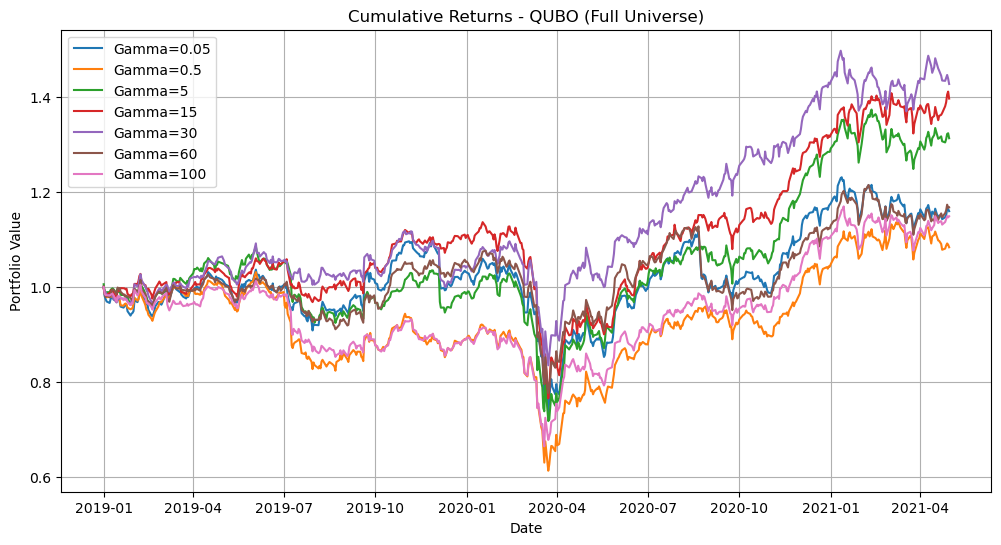

QUBO FULL UNIVERSE PERFORMANCE


,Gamma,Annualized Return,Annualized Volatility,Sharpe Ratio
0,0.050000,9.18%,23.23%,0.395
1,0.500000,5.90%,21.88%,0.270
2,5.000000,14.30%,21.89%,0.653
3,15.000000,16.86%,21.30%,0.792
4,30.000000,17.51%,19.95%,0.878
5,60.000000,8.85%,20.34%,0.435
6,100.000000,8.01%,19.78%,0.405


In [240]:
summary_qubo_full = evaluate_portfolios(
    portfolio_returns_qubo_full,
    "QUBO (Full Universe)"
)

print("QUBO FULL UNIVERSE PERFORMANCE")
display(summary_qubo_full.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}"
}))

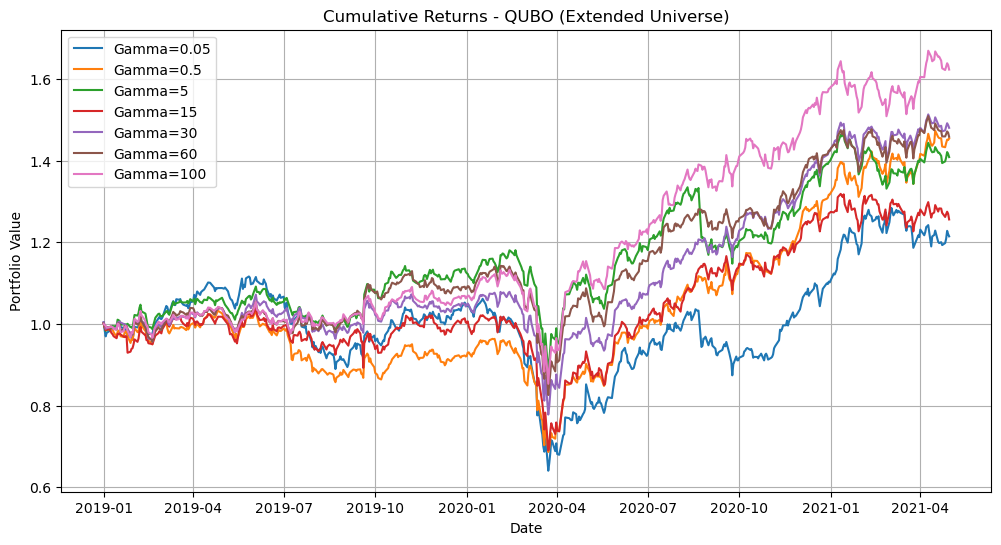

QUBO EXTENDED UNIVERSE PERFORMANCE


,Gamma,Annualized Return,Annualized Volatility,Sharpe Ratio
0,0.050000,11.77%,25.50%,0.461
1,0.500000,18.71%,21.71%,0.862
2,5.000000,17.13%,20.74%,0.826
3,15.000000,12.75%,23.62%,0.540
4,30.000000,19.33%,20.95%,0.923
5,60.000000,18.62%,20.65%,0.902
6,100.000000,23.23%,20.36%,1.141


In [242]:
summary_qubo_ext = evaluate_portfolios(
    portfolio_returns_qubo_ext,
    "QUBO (Extended Universe)"
)

print("QUBO EXTENDED UNIVERSE PERFORMANCE")
display(summary_qubo_ext.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}"
}))

-----

### Full-Scale QUBO with Discretized Weights (Stress Test)

We attempt the discretized-weight QUBO formulation on the full asset universe.

Due to the exponential growth in variables and interactions, this experiment serves as a stress test to evaluate scalability and solution stability under simulated annealing.

### Step 1: Building QUBO with Discretized Weights

We extend the binary QUBO formulation by encoding portfolio weights using multiple binary variables per asset.

Each asset weight is approximated as:

$w_i = w_{i,\min} + (w_{i,\max} - w_{i,\min}) * \sum_k c_k x_{i,k}$

where:
- $x_{i,k} ∈ {0,1}$
- $c_k$ are binary coefficients (e.g., 0.5, 0.25 for B=2)
- $[w_{i,\min}, w_{i,\max}]$ defines the allowed range for each asset


This transforms the problem from N variables to N × B variables.

We then construct a QUBO of the form:

min  $$-μᵀw + γ wᵀΣw + λ (\sum w_i- 1)²$$

which is expressed entirely in terms of binary variables.

In [120]:
import numpy as np

def build_weight_qubo_ranges(r, Sigma, w_min, w_max, gamma=5, lam=50, B=2):
    N = len(r)
    M = N * B  # total binary variables

    # binary coefficients (coarse)
    coeffs = np.array([1/(2**(k+1)) for k in range(B)])  # e.g. [0.5, 0.25]

    Q = np.zeros((M, M))

    # helper: map (asset i, bit k) → index
    def idx(i, k):
        return i * B + k

    # scaling per asset
    scale = (w_max - w_min)

    # ---- Linear term: -mu^T w ----
    for i in range(N):
        for k in range(B):
            Q[idx(i,k), idx(i,k)] += -r[i] * scale[i] * coeffs[k]

    # ---- Quadratic term: gamma * w^T Sigma w ----
    for i in range(N):
        for j in range(i, N):
            for k in range(B):
                for l in range(B):
                    Q[idx(i,k), idx(j,l)] += (
                        gamma * Sigma[i,j] * scale[i]*scale[j] * coeffs[k]*coeffs[l]
                    )

    # ---- Budget constraint: (sum w_i - 1)^2 ----
    # quadratic part
    for i in range(N):
        for j in range(i, N):
            for k in range(B):
                for l in range(B):
                    Q[idx(i,k), idx(j,l)] += (
                        lam * scale[i]*scale[j] * coeffs[k]*coeffs[l]
                    )

    # linear part
    for i in range(N):
        for k in range(B):
            Q[idx(i,k), idx(i,k)] += -2 * lam * scale[i] * coeffs[k]

    return Q

### Step 2: Constructing the Full QUBO Matrix

We now construct the QUBO matrix for the full universe using discretized weights.

Key points:
- Each asset is represented using B binary variables
- Total variables = N × B
- The Q matrix encodes:
  - Expected return (linear term)
  - Risk via covariance (quadratic term)
  - Budget constraint (sum of weights = 1)

This step significantly increases dimensionality compared to the original binary selection model.

In [147]:
B=3
def matrix_to_qubo_dict(Q):
    Q_dict = {}
    N = Q.shape[0]
    
    for i in range(N):
        for j in range(i, N):
            val = Q[i, j]
            if abs(val) > 1e-10:
                Q_dict[(i, j)] = val
                
    return Q_dict


# -------- FULL UNIVERSE --------
w_min_full = np.zeros(N_full)
w_max_full = 0.2 * np.ones(N_full)

Q_full_big = build_weight_qubo_ranges(
    r_full,
    Sigma_full,
    w_min_full,
    w_max_full,
    gamma=gamma,
    lam=lam,
    B=B
)

Q_dict_full_big = matrix_to_qubo_dict(Q_full_big)
print("Full QUBO terms:", len(Q_dict_full_big))


# -------- EXTENDED UNIVERSE --------
w_min_ext = np.zeros(N_extended)
w_max_ext = 0.2 * np.ones(N_extended)

Q_ext_big = build_weight_qubo_ranges(
    r_extended,
    Sigma_ext,
    w_min_ext,
    w_max_ext,
    gamma=gamma,
    lam=lam,
    B=B
)

Q_dict_ext_big = matrix_to_qubo_dict(Q_ext_big)
print("Extended QUBO terms:", len(Q_dict_ext_big))

Full QUBO terms: 11325
Extended QUBO terms: 6555


### Step 3: Solving QUBO using Simulated Annealing

We now solve the QUBO formulations for both universes using simulated annealing.

Due to the increased problem size and density, we use a limited number of reads to control runtime.

In [155]:
import neal

sampler = neal.SimulatedAnnealingSampler()

# --- FULL ---
sampleset_full_big = sampler.sample_qubo(
    Q_dict_full_big,
    num_reads=1000
)

best_full_big = sampleset_full_big.first.sample


# --- EXTENDED ---
sampleset_ext_big = sampler.sample_qubo(
    Q_dict_ext_big,
    num_reads=1000
)

best_ext_big = sampleset_ext_big.first.sample

### Step 4: Decoding Binary Solution into Portfolio Weights

The annealer returns binary variables. We convert these back into asset weights using the discretization scheme:

$w_i = w_{i,\min} + (w_{i,\max} - w_{i,\min}) \sum_k c_k x_{i,k}$

We then normalize the weights so they sum to 1.

In [157]:
def decode_weights_ranges(sample, w_min, w_max, B):
    N = len(w_min)
    coeffs = np.array([1/(2**(k+1)) for k in range(B)])

    w = np.zeros(N)

    for i in range(N):
        val = 0
        for k in range(B):
            val += coeffs[k] * sample[i*B + k]

        w[i] = w_min[i] + (w_max[i] - w_min[i]) * val

    # normalize
    if w.sum() > 0:
        w = w / w.sum()

    return w


# FULL
w_full_big = decode_weights_ranges(
    best_full_big,
    w_min_full,
    w_max_full,
    B
)

# EXTENDED
w_ext_big = decode_weights_ranges(
    best_ext_big,
    np.zeros(N_extended),
    0.2 * np.ones(N_extended),
    B
)

print("Full sum:", w_full_big.sum())
print("Extended sum:", w_ext_big.sum())

Full sum: 1.0000000000000002
Extended sum: 1.0


In [161]:
def print_top_assets(weights, assets, top_k=10):
    pairs = list(zip(assets, weights))
    pairs_sorted = sorted(pairs, key=lambda x: -x[1])
    
    for a, w in pairs_sorted[:top_k]:
        print(a, round(w, 4))


print("=== FULL UNIVERSE ===")
print_top_assets(w_full_big, assets_full)

print("\n=== EXTENDED UNIVERSE ===")
print_top_assets(w_ext_big, assets_extended)

=== FULL UNIVERSE ===
BHARTIARTL 0.038
CIPLA 0.038
COALINDIA 0.038
DRREDDY 0.038
GAIL 0.038
GRASIM 0.038
HEROMOTOCO 0.038
HINDUNILVR 0.038
ITC 0.038
NESTLEIND 0.038

=== EXTENDED UNIVERSE ===
ASIANPAINT 0.038
BAJFINANCE 0.038
BHARTIARTL 0.038
BPCL 0.038
BRITANNIA 0.038
CIPLA 0.038
DRREDDY 0.038
EICHERMOT 0.038
GRASIM 0.038
HDFCBANK 0.038


In [163]:
# --- NEW PARAMETERS ---
gamma_new = 1      # reduce risk dominance
lam_new = 5        # reduce constraint dominance

# amplify return signal
r_full_scaled = 10 * r_full
r_ext_scaled  = 10 * r_extended


# -------- FULL --------
Q_full_new = build_weight_qubo_ranges(
    r_full_scaled,
    Sigma_full,
    np.zeros(N_full),
    0.2 * np.ones(N_full),
    gamma=gamma_new,
    lam=lam_new,
    B=3
)

Q_dict_full_new = matrix_to_qubo_dict(Q_full_new)


# -------- EXTENDED --------
Q_ext_new = build_weight_qubo_ranges(
    r_ext_scaled,
    Sigma_ext,
    np.zeros(N_extended),
    0.2 * np.ones(N_extended),
    gamma=gamma_new,
    lam=lam_new,
    B=3
)

Q_dict_ext_new = matrix_to_qubo_dict(Q_ext_new)

In [165]:
import neal

sampler = neal.SimulatedAnnealingSampler()

sampleset_full_new = sampler.sample_qubo(Q_dict_full_new, num_reads=500)
sampleset_ext_new  = sampler.sample_qubo(Q_dict_ext_new,  num_reads=500)

best_full_new = sampleset_full_new.first.sample
best_ext_new  = sampleset_ext_new.first.sample

In [167]:
w_full_new = decode_weights_ranges(
    best_full_new,
    np.zeros(N_full),
    0.2 * np.ones(N_full),
    B=3
)

w_ext_new = decode_weights_ranges(
    best_ext_new,
    np.zeros(N_extended),
    0.2 * np.ones(N_extended),
    B=3
)


print("=== FULL (Adjusted) ===")
print_top_assets(w_full_new, assets_full)

print("\n=== EXTENDED (Adjusted) ===")
print_top_assets(w_ext_new, assets_extended)

=== FULL (Adjusted) ===
BHARTIARTL 0.0805
COALINDIA 0.0805
HEROMOTOCO 0.0805
MARUTI 0.0805
SUNPHARMA 0.0805
AXISBANK 0.0345
BAJAJ-AUTO 0.0345
BRITANNIA 0.0345
CIPLA 0.0345
DRREDDY 0.0345

=== EXTENDED (Adjusted) ===
BHARTIARTL 0.0769
BPCL 0.0769
GAIL 0.0769
HEROMOTOCO 0.0769
HINDUNILVR 0.0769
IOC 0.0769
KOTAKBANK 0.0769
MM 0.0769
ONGC 0.0769
ASIANPAINT 0.033
